In [1]:
import json
import sys
import time
import os
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv

import pandas as pd
import numpy as np

from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


# Load environment variables from current directory .env and override existing ones
load_dotenv(".env", override=True)

# load api key from environment
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in .env file")

client = OpenAI(api_key=api_key)

In [2]:
DISTANCE_TRESHOLD = .7

In [3]:
df = pd.read_json("hf://datasets/HannahRoseKirk/prism-alignment/survey.jsonl", lines=True)

In [4]:
df.columns

Index(['user_id', 'survey_only', 'num_completed_conversations', 'consent',
       'consent_age', 'lm_familiarity', 'lm_indirect_use', 'lm_direct_use',
       'lm_frequency_use', 'self_description', 'system_string', 'age',
       'gender', 'employment_status', 'education', 'marital_status',
       'english_proficiency', 'study_id', 'study_locale', 'religion',
       'ethnicity', 'location', 'lm_usecases', 'stated_prefs',
       'order_lm_usecases', 'order_stated_prefs', 'generated_datetime',
       'timing_duration_s', 'timing_duration_mins', 'included_in_US_REP',
       'included_in_UK_REP', 'included_in_balanced_subset'],
      dtype='object')

In [5]:
# Use the self-written constitution with respect to how participants want AI Language models to behave
self_written_ai_principles = df["system_string"].dropna().tolist()

# Use the self-written core pricniples and values (general for life)
self_written_guiding_principles = df["self_description"].dropna().tolist()

In [6]:
# function for getting embeddings from API
def get_embedding(principle):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.embeddings.create(
                input=principle,
                model="text-embedding-3-small"
            )
            return response.data[0].embedding
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)


In [7]:
def summarize_cluster(cluster, prompt, summary_prompt):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.chat.completions.create(
                model="gpt-4.1-2025-04-14",
                messages=[
                    {"role": "system", "content": summary_prompt},
                    {"role": "user", "content": prompt}
                ],
            )
            summary = response.choices[0].message.content.strip()
            return({
                "cluster_id": cluster["cluster_id"],
                "summarized_principle": summary,
                "original_principles": cluster["principles"]
            })
            break
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)

In [8]:
# Decide which principles set to use 

use_principles_for_ai = True

if use_principles_for_ai:
    principles = self_written_ai_principles
    cluster_output = f'self_written_ai_principles_th={DISTANCE_TRESHOLD}_principles_clusters_test.json'
    summarized_principles_output = f'self_written_ai_principles_th={DISTANCE_TRESHOLD}_summarized_test.json'
else:
    principles = self_written_guiding_principles
    cluster_output = f'self_written_guiding_principles_th={DISTANCE_TRESHOLD}_principles_clusters.json'
    summarized_principles_output = f'self_written_guiding_principles_th={DISTANCE_TRESHOLD}_summarized.json'



In [9]:
emb_path = "self_written_ai_principles_embeddings.npy"

if os.path.exists(emb_path):
    print(f"Loading embeddings from {emb_path}")
    embeddings = np.load(emb_path)
    embeddings = np.asarray(embeddings, dtype=np.float32)
else:
    print("No saved embeddings found. Computing embeddings now...")
    embeddings = []
    for p in tqdm(self_written_ai_principles, desc="Computing embeddings"):
        embeddings.append(get_embedding(p))

    embeddings = np.vstack(embeddings)
    np.save(emb_path, embeddings)
    print(f"Saved embeddings to {emb_path}")

print("Embeddings shape:", embeddings.shape)

Loading embeddings from self_written_ai_principles_embeddings.npy
Embeddings shape: (1500, 1536)


In [10]:
#run a heirarchical clustering algorithm on the embeddings to group similar principles together

clustering_model = AgglomerativeClustering(n_clusters=None, linkage = 'average', metric = 'cosine', distance_threshold=DISTANCE_TRESHOLD)  # Adjust distance_threshold as needed
labels = clustering_model.fit_predict(embeddings)


In [11]:
#print number of clusters
num_clusters = len(set(labels))
print(f"Number of clusters: {num_clusters}")

#save clusters & principles to json
clusters = {}
for i, label in enumerate(labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(principles[i])

clusters_output = []
for i in range(len(clusters)):
    clusters_output.append({
        "cluster_id": i,
        "principles": clusters[i]
    })

with open(cluster_output, 'w') as f:
    json.dump(clusters_output, f, indent=4)


Number of clusters: 25


(array([24.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([1.0000e+00, 4.8500e+01, 9.6000e+01, 1.4350e+02, 1.9100e+02,
        2.3850e+02, 2.8600e+02, 3.3350e+02, 3.8100e+02, 4.2850e+02,
        4.7600e+02, 5.2350e+02, 5.7100e+02, 6.1850e+02, 6.6600e+02,
        7.1350e+02, 7.6100e+02, 8.0850e+02, 8.5600e+02, 9.0350e+02,
        9.5100e+02, 9.9850e+02, 1.0460e+03, 1.0935e+03, 1.1410e+03,
        1.1885e+03, 1.2360e+03, 1.2835e+03, 1.3310e+03, 1.3785e+03,
        1.4260e+03]),
 <BarContainer object of 30 artists>)

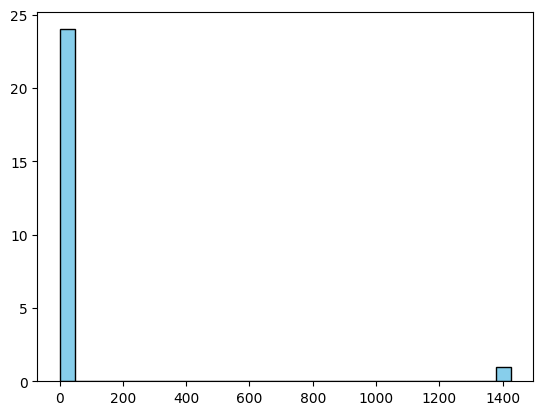

In [12]:
cluster_sizes = []
for cluster in clusters_output:
    cluster_sizes.append(len(cluster['principles']))


plt.hist(cluster_sizes, bins=30, color='skyblue', edgecolor='black')


In [15]:
# use gpt 4.1 to summarize each cluster of principles into a single principle that captures the general idea of each
with open('principle_summary_prompt.txt', 'r') as f:
    summary_prompt = f.read()
summary_prompt

'# Identity\n\nYou are an assistant that summarizes multiple similar principles, into a single principle for AI alignment. \nSome individual principles may be contextual, but the summary principles that you generate should capture the general concept that is\nshared between principles, without focusing on contextual elements, unless the contextual elements are shared between individual principles. \n\n# Instructions\n\n* Combine the presented principles into a single principle that captures the general idea and points of each of the presented principles.\n* Do not highlight contextual details of the presented principles in the summarized version.\n* Respond with only the summarized principle, do not add any formatting such as lists or dashes.\n* Rather than listing the components of individual principles, try to synthesize the main ideas.\n* Do not provide any additional commentary or thought process, only the summary principle.\n'

In [17]:
k = 3  # number of principles to include in the prompt

summarized_principles = []

for cluster in tqdm(clusters_output):

    # Calculate centroid of cluster embeddings

    cluster_embeddings = [embeddings[i] for i, label in enumerate(labels) if label == cluster["cluster_id"]]
    centroid = np.mean(cluster_embeddings, axis=0)

    # Find the k principles closest to the centroid
    distances = [np.linalg.norm(np.array(embedding) - centroid) for embedding in cluster_embeddings]
    closest_indices = np.argsort(distances)[:k]
    closest_principles = [cluster["principles"][i] for i in closest_indices]


    principles_text = "\n".join([f"{i+1}. {p}" for i, p in enumerate(closest_principles)])
    prompt = f"\n\nPrinciples:\n{principles_text}\n\nSummarized Principle:"
    
    summarized_principles.append(summarize_cluster(cluster, prompt, summary_prompt))

with open(summarized_principles_output, 'w') as f:
    json.dump(summarized_principles, f, indent=4)

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [00:25<00:00,  1.03s/it]
